In [3]:
from frap_utils import *

## Generate list of paths

In [4]:
# Create list of paths to the final files
sample_names = ["WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

# Path to main folder
root_folder = Path("/mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP")

# Path to the folder to save final graphs
graphs_folder = check_dir_exists(root_folder / "final_graphs")

list_of_paths = []
for sample in sample_names:
    filepath = check_file_exists(root_folder / sample / "EasyFRAP" / f"easyFRAP_Final_Data_{sample}_MFI_filtrated.csv")
    list_of_paths.append(filepath)
    print(f"File: {filepath}")

print(f"There are {len(list_of_paths)} files founded.")

File: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/WT/EasyFRAP/easyFRAP_Final_Data_WT_MFI_filtrated.csv
File: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/MGS1/EasyFRAP/easyFRAP_Final_Data_MGS1_MFI_filtrated.csv
File: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/MGS2/EasyFRAP/easyFRAP_Final_Data_MGS2_MFI_filtrated.csv
File: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/MGS3/EasyFRAP/easyFRAP_Final_Data_MGS3_MFI_filtrated.csv
File: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/MGS4/EasyFRAP/easyFRAP_Final_Data_MGS4_MFI_filtrated.csv
File: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/MGS5/EasyFRAP/easyFRAP_Final_Data_MGS5_MFI_filtrated.csv
There are 6 files founded.


## Import data

In [5]:
# Import data
dfs = []  # list of DataFrames

for p in list_of_paths:
    df = pd.read_csv(p, header=0)
    dfs.append(df)

print(f"Loaded {len(dfs)} files.")

Loaded 6 files.


## Histograms of nuclei MFI

Plot for WT is saved in the directory: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/final_graphs.


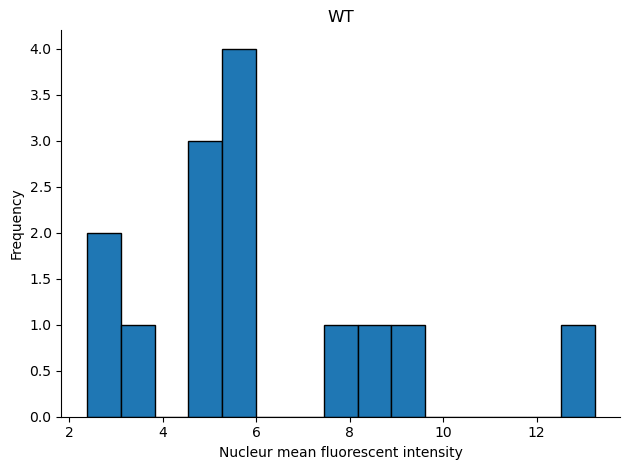

Plot for MGS1 is saved in the directory: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/final_graphs.


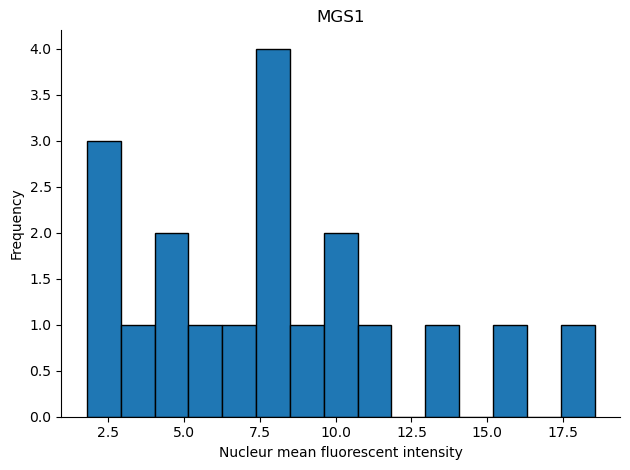

Plot for MGS2 is saved in the directory: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/final_graphs.


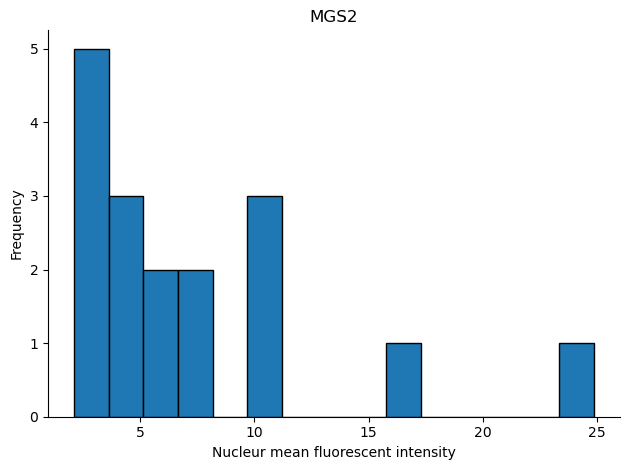

Plot for MGS3 is saved in the directory: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/final_graphs.


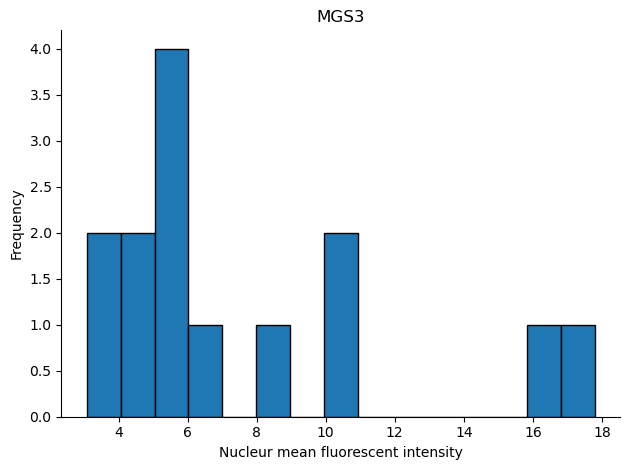

Plot for MGS4 is saved in the directory: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/final_graphs.


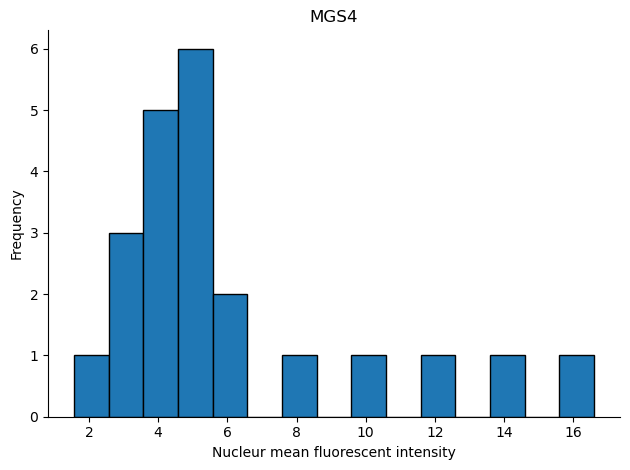

Plot for MGS5 is saved in the directory: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/final_graphs.


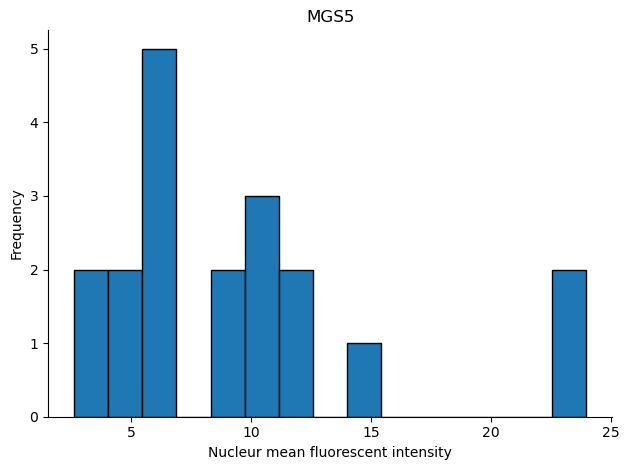

In [6]:
# Histograms of Nuclear MFI
for i, sample_name in zip(range(len(dfs)), sample_names):

    var = dfs[i]["mean_intensity"]
    plt.hist(var, bins = 15, edgecolor='black')
    plt.xlabel("Nucleur mean fluorescent intensity")
    plt.ylabel("Frequency")
    plt.title(sample_names[i])

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()

    # Save image
    plt.savefig(graphs_folder/f"Nuclei_MFI_hist_{sample_name}.png", dpi=300, bbox_inches="tight")
    print(f"Plot for {sample_name} is saved in the directory: {graphs_folder}.")

    plt.show()

## *Optional: delete outliers*

In [7]:
dfs[2] = dfs[2].drop(index=1)

## *Optional: extra filtration based on the nuclei MFI*

In [8]:
threshold_MFI = 16
dfs_filtered = []
for i in range(len(dfs)):
    df_filtered = dfs[i][dfs[i]['mean_intensity'] < threshold_MFI]
    dfs_filtered.append(df_filtered)
    print(f"{i}: keep {len(df_filtered)} out of {len(dfs[i])} rows.")

0: keep 14 out of 14 rows.
1: keep 17 out of 19 rows.
2: keep 15 out of 16 rows.
3: keep 12 out of 14 rows.
4: keep 21 out of 22 rows.
5: keep 17 out of 19 rows.


## Boxplots

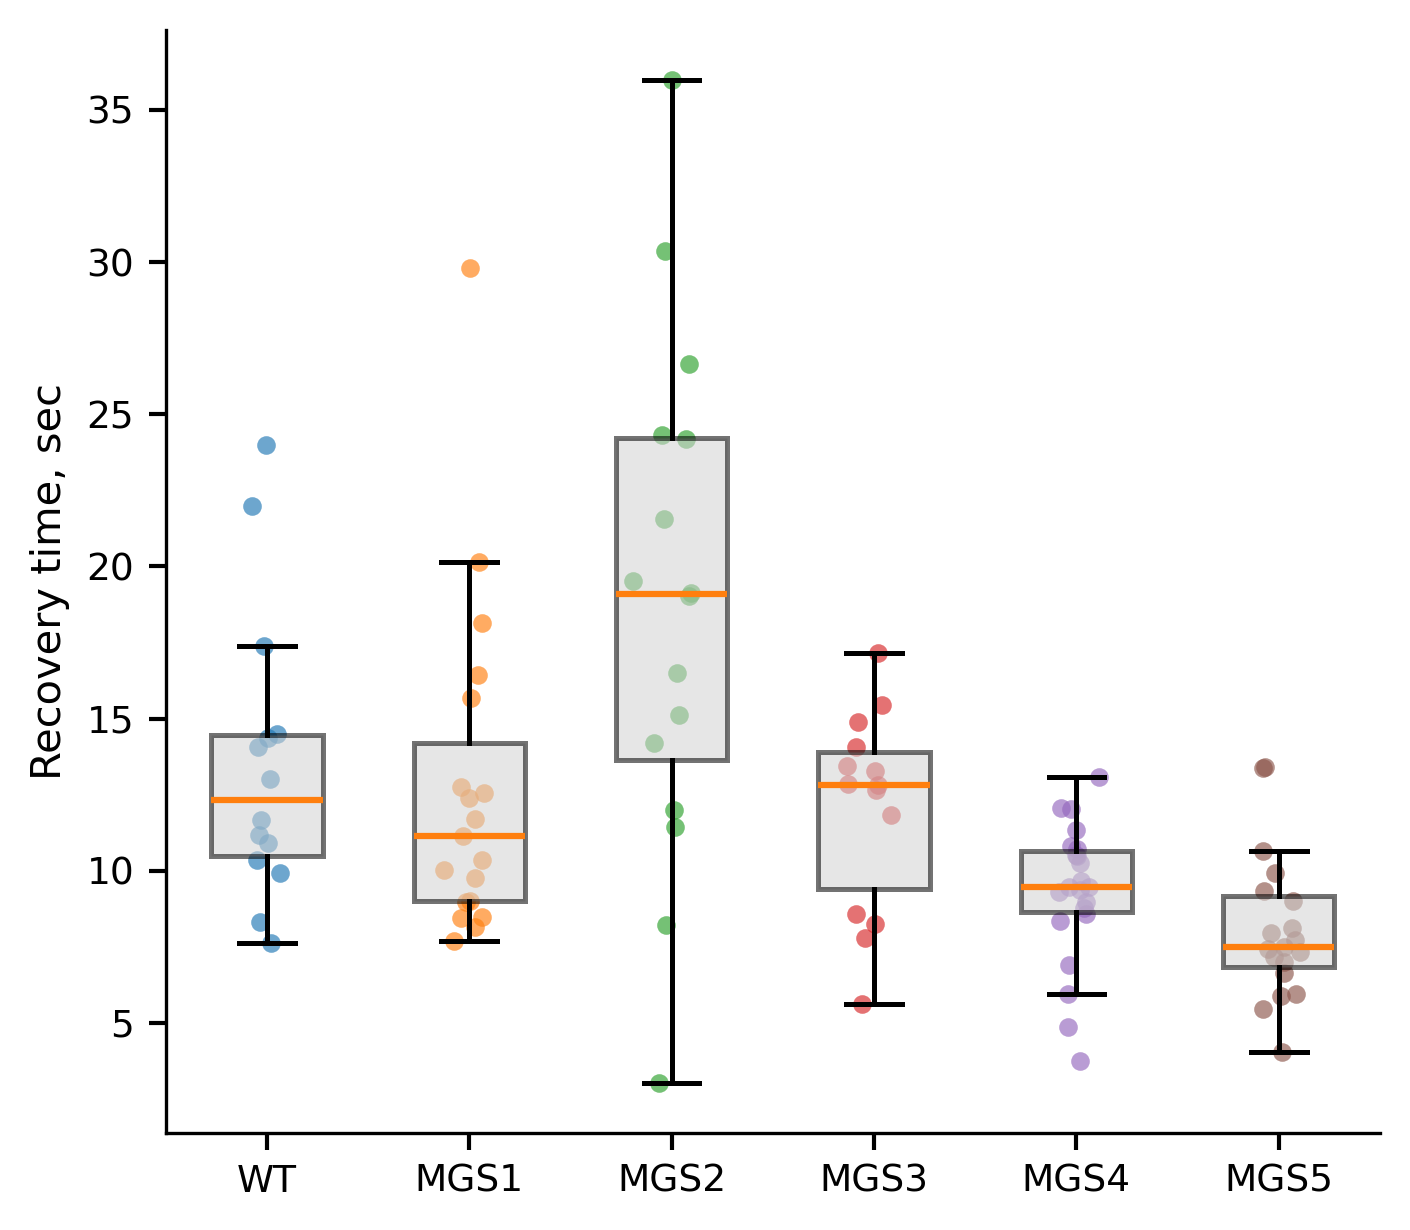

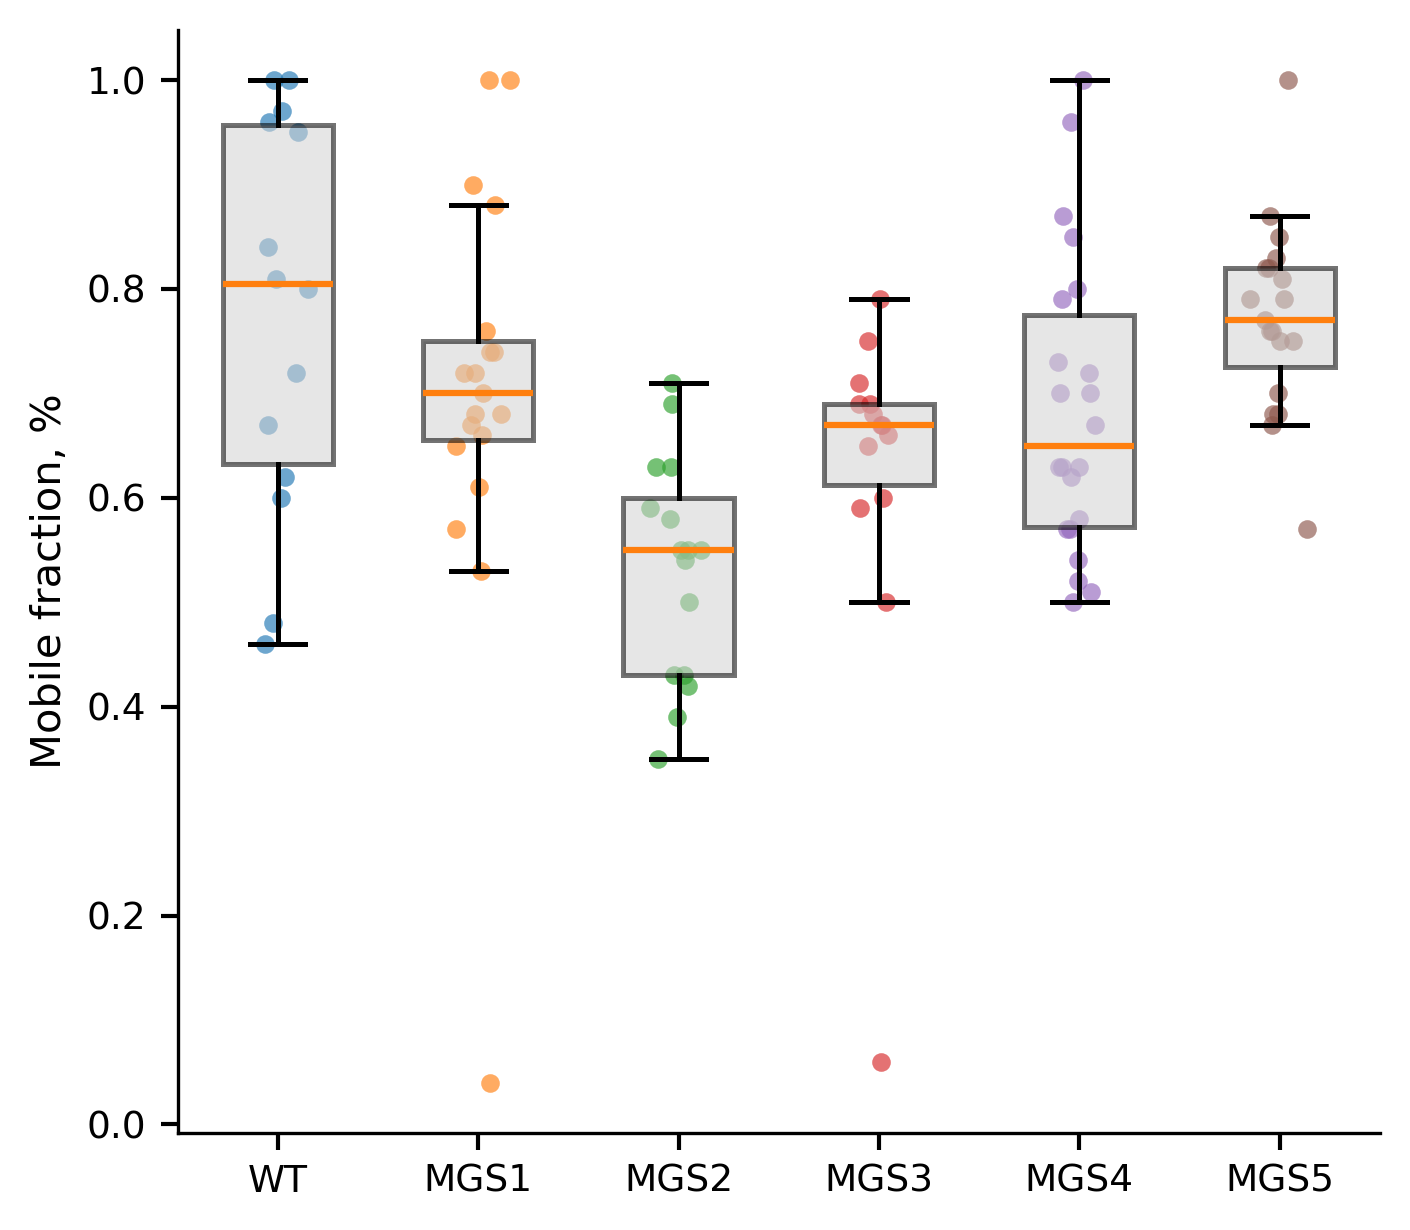

In [9]:
args = [{'var': "T-half", 'ylabel':'Recovery time, sec', 'title':''},
        {'var': "Mobile Fraction", 'ylabel':'Mobile fraction, %', 'title': ''},
]

for arg in args:
    beautiful_boxplot(
        df_list=[
                dfs[0][arg['var']],
                dfs[1][arg['var']],
                dfs[2][arg['var']],
                dfs[3][arg['var']],
                dfs[4][arg['var']],
                dfs[5][arg['var']]
                ],
        labels=sample_names,
        ylabel=arg['ylabel'],
        title=arg['title']
    )

## Mann-Whitney statistical analysis

### Mobile fraction, %

In [10]:
mannwhitneyu_stats(data = dfs,
                  column_name = 'Mobile Fraction',
                  reference_index = 0,
                  save = True,
                  output_folder = graphs_folder)

The results are saved into the folder: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/final_graphs


,comparison,stat,p_value,significant
0,WT vs MGS1,158.5,0.361798,False
1,WT vs MGS2,192.0,0.000942,True
2,WT vs MGS3,140.5,0.053402,True
3,WT vs MGS4,198.5,0.152953,False
4,WT vs MGS5,140.0,0.812667,False


### Half-time of recovery

In [12]:
mannwhitneyu_stats(data = dfs,
                  column_name = 'T-half',
                  reference_index = 0,
                  save = True,
                  output_folder = graphs_folder)

The results are saved into the folder: /mnt/c/users/elopatukhin/Desktop/Data_processing/050326_U2OS_live_FRAP/final_graphs


,comparison,stat,p_value,significant
0,WT vs MGS1,154.0,0.455226,False
1,WT vs MGS2,61.0,0.035789,True
2,WT vs MGS3,106.0,0.730389,False
3,WT vs MGS4,243.0,0.004081,True
4,WT vs MGS5,236.5,0.000175,True
